In [18]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('medical_insurance_2026_kaggle.csv')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
print(df.head())

Dataset loaded successfully!
Shape: (1337, 24)
Columns: ['record_date', 'year', 'quarter', 'age', 'age_group', 'sex', 'sex_female', 'bmi', 'bmi_category', 'children', 'smoker', 'smoker_flag', 'is_high_risk', 'risk_score', 'region', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest', 'charges', 'monthly_premium_est', 'charges_per_child', 'insurance_tier', 'bmi_age_interaction']

First 5 rows:
  record_date  year  quarter  age            age_group     sex  sex_female  \
0  2024-02-01  2024        1   19  Young Adult (18-25)  female           1   
1  2024-12-30  2024        4   18  Young Adult (18-25)    male           0   
2  2023-05-11  2023        2   28        Adult (26-35)    male           0   
3  2024-07-18  2024        3   33        Adult (26-35)    male           0   
4  2024-02-05  2024        1   32        Adult (26-35)    male           0   

     bmi   bmi_category  children  ...     region  region_northeast  \
0  27.90     Overweight         0  ..

In [19]:
# Implement Bivariate Normal PDF from Scratch
def bivariate_normal_pdf(x, y, mu_x, mu_y, sigma_x, sigma_y, rho):
    """
    Calculate bivariate normal probability density function.

    Parameters:
    x, y : point coordinates
    mu_x, mu_y : means
    sigma_x, sigma_y : standard deviations
    rho : correlation coefficient (-1 to 1)
    """
    # Calculate the quadratic form
    z = ((x - mu_x)**2 / sigma_x**2 -
         2 * rho * (x - mu_x) * (y - mu_y) / (sigma_x * sigma_y) +
         (y - mu_y)**2 / sigma_y**2)

    # Calculate normalization constant
    normalization = 1 / (2 * np.pi * sigma_x * sigma_y * np.sqrt(1 - rho**2))

    # Calculate PDF
    pdf = normalization * np.exp(-z / (2 * (1 - rho**2)))

    return pdf

print("Bivariate normal PDF function created successfully!")

Bivariate normal PDF function created successfully!


BIVARIATE PARAMETERS (Age vs BMI)
Age - Mean: 39.22 years, Std: 14.04
BMI - Mean: 30.66, Std: 6.10
Covariance: 9.36
Correlation (ρ): 0.1093


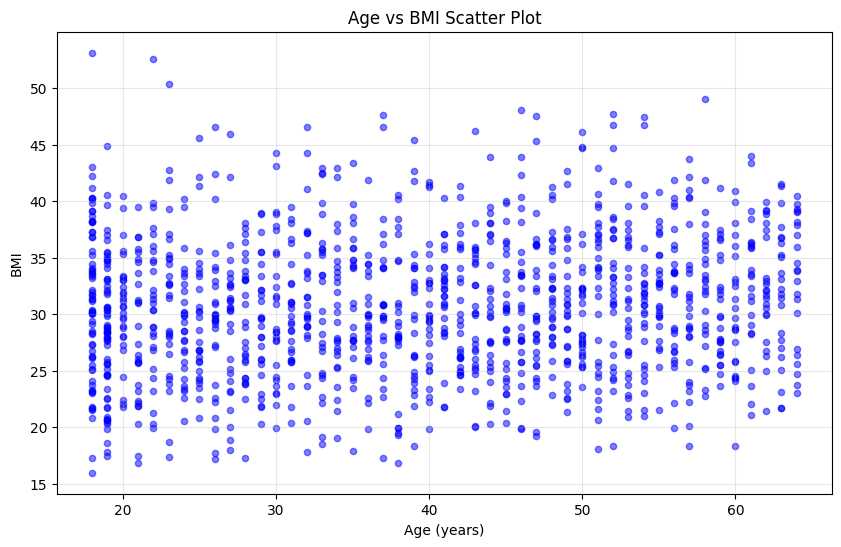

In [20]:
# Calculate Parameters for Age and BMI
# Select variables for analysis

X = df['age'].values
Y = df['bmi'].values

# Calculate means
mu_x = np.mean(X)
mu_y = np.mean(Y)

# Calculate standard deviations
sigma_x = np.std(X)
sigma_y = np.std(Y)

# Calculate covariance and correlation
cov_xy = np.mean((X - mu_x) * (Y - mu_y))
rho = cov_xy / (sigma_x * sigma_y)

print("="*50)
print("BIVARIATE PARAMETERS (Age vs BMI)")
print("="*50)
print(f"Age - Mean: {mu_x:.2f} years, Std: {sigma_x:.2f}")
print(f"BMI - Mean: {mu_y:.2f}, Std: {sigma_y:.2f}")
print(f"Covariance: {cov_xy:.2f}")
print(f"Correlation (ρ): {rho:.4f}")
print("="*50)

# Quick visualization to see the data distribution
plt.figure(figsize=(10, 6))
plt.scatter(X, Y, alpha=0.5, c='blue', s=20)
plt.xlabel('Age (years)')
plt.ylabel('BMI')
plt.title('Age vs BMI Scatter Plot')
plt.grid(True, alpha=0.3)
plt.show()

In [21]:
# Create Grid and Calculate PDF Values
# Create grid points for contour plot (3 standard deviations range)
x_grid = np.linspace(mu_x - 3*sigma_x, mu_x + 3*sigma_x, 50)
y_grid = np.linspace(mu_y - 3*sigma_y, mu_y + 3*sigma_y, 50)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid)

# Initialize PDF matrix
Z = np.zeros_like(X_grid)

# Calculate PDF at each grid point
print("Calculating PDF values for contour plot...")
print(f"Grid size: {len(x_grid)} x {len(y_grid)} = {len(x_grid) * len(y_grid)} points")

for i in range(len(x_grid)):
    for j in range(len(y_grid)):
        Z[j, i] = bivariate_normal_pdf(x_grid[i], y_grid[j],
                                       mu_x, mu_y, sigma_x, sigma_y, rho)

print(f"Done! Calculated {Z.shape[0] * Z.shape[1]:,} PDF values")
print(f"PDF range: [{np.min(Z):.6f}, {np.max(Z):.6f}]")
print(f"\nGrid range:")
print(f"  Age: [{x_grid[0]:.1f} to {x_grid[-1]:.1f}] years")
print(f"  BMI: [{y_grid[0]:.1f} to {y_grid[-1]:.1f}]")

Calculating PDF values for contour plot...
Grid size: 50 x 50 = 2500 points
Done! Calculated 2,500 PDF values
PDF range: [0.000000, 0.001864]

Grid range:
  Age: [-2.9 to 81.3] years
  BMI: [12.4 to 49.0]


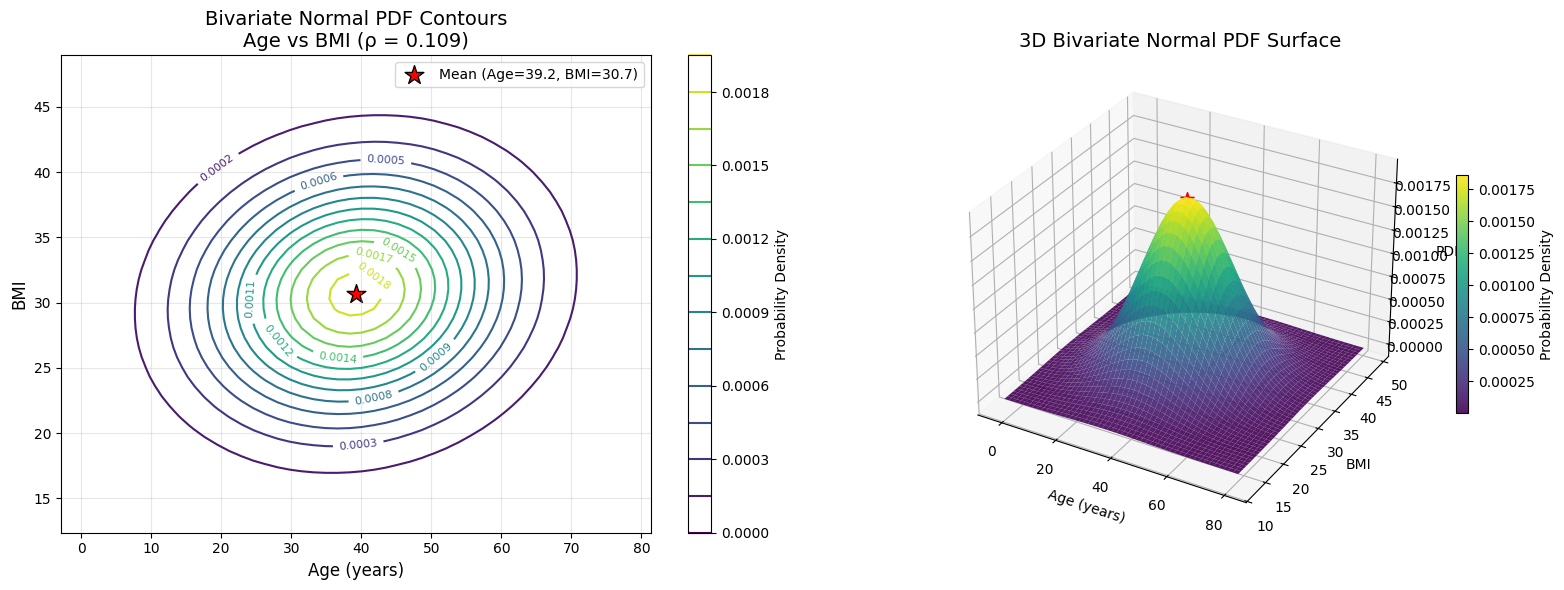

In [22]:
# Create figure with 2 subplots (one for contour, one for 3D)
fig = plt.figure(figsize=(16, 6))

# Plot 1: Contour plot of bivariate normal PDF
ax1 = fig.add_subplot(121)
contour = ax1.contour(X_grid, Y_grid, Z, levels=15, cmap='viridis')
ax1.clabel(contour, inline=True, fontsize=8, fmt='%.4f')
ax1.scatter(mu_x, mu_y, color='red', s=200, marker='*', label=f'Mean (Age={mu_x:.1f}, BMI={mu_y:.1f})', edgecolor='black')
ax1.set_xlabel('Age (years)', fontsize=12)
ax1.set_ylabel('BMI', fontsize=12)
ax1.set_title(f'Bivariate Normal PDF Contours\nAge vs BMI (ρ = {rho:.3f})', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add colorbar for contour
plt.colorbar(contour, ax=ax1, label='Probability Density')

# Plot 2: 3D surface plot
ax2 = fig.add_subplot(122, projection='3d')
surf = ax2.plot_surface(X_grid, Y_grid, Z, cmap='viridis', alpha=0.9, edgecolor='none')
ax2.scatter([mu_x], [mu_y], [np.max(Z)], color='red', s=100, marker='*', label='Peak')
ax2.set_xlabel('Age (years)', fontsize=10)
ax2.set_ylabel('BMI', fontsize=10)
ax2.set_zlabel('PDF', fontsize=10)
ax2.set_title('3D Bivariate Normal PDF Surface', fontsize=14)
fig.colorbar(surf, ax=ax2, shrink=0.5, label='Probability Density')

plt.tight_layout()
plt.show()


In [23]:
# VISUALIZATION INTERPRETATION
print("\n" + "="*60)
print("VISUALIZATION INTERPRETATION")
print("="*60)
print(f"""
From the data with:
• Mean Age: {mu_x:.1f} years
• Mean BMI: {mu_y:.1f}
• Correlation: {rho:.3f}

LEFT PLOT :
- The elliptical rings show equal probability density
- Center (red star) at age={mu_x:.1f}, BMI={mu_y:.1f} has highest density ({np.max(Z):.6f})
- Each ring represents decreasing probability as you move away from the mean
- The slight tilt in ellipses reflects the weak positive correlation (ρ={rho:.3f})

RIGHT PLOT :
- Bell-shaped surface typical of bivariate normal distribution
- Peak directly above the mean (red star)
- Spread in age direction (σ={sigma_x:.1f}) is wider than BMI direction (σ={sigma_y:.1f})
- Surface height represents probability density
""")


VISUALIZATION INTERPRETATION

From the data with:
• Mean Age: 39.2 years
• Mean BMI: 30.7
• Correlation: 0.109

LEFT PLOT :
- The elliptical rings show equal probability density
- Center (red star) at age=39.2, BMI=30.7 has highest density (0.001864)
- Each ring represents decreasing probability as you move away from the mean
- The slight tilt in ellipses reflects the weak positive correlation (ρ=0.109)

RIGHT PLOT :
- Bell-shaped surface typical of bivariate normal distribution
- Peak directly above the mean (red star)
- Spread in age direction (σ=14.0) is wider than BMI direction (σ=6.1)
- Surface height represents probability density



In [24]:
# Verify PDF Properties
dx = x_grid[1] - x_grid[0]
dy = y_grid[1] - y_grid[0]
total_probability = np.sum(Z) * dx * dy

print("="*60)
print("PDF VERIFICATION")
print("="*60)
print(f"Grid spacing: dx={dx:.2f} years, dy={dy:.2f} BMI units")
print(f"Total probability (∫∫ f(x,y) dx dy): {total_probability:.4f}")
print(f"Should be close to 1.0: {'✅' if 0.95 < total_probability < 1.05 else '⚠️'}")

# Find peak location
max_row, max_col = np.unravel_index(np.argmax(Z), Z.shape)
peak_age = x_grid[max_col]
peak_bmi = y_grid[max_row]
peak_value = np.max(Z)

print(f"\nPeak PDF location: Age={peak_age:.1f}, BMI={peak_bmi:.1f}")
print(f"Actual mean values: Age={mu_x:.1f}, BMI={mu_y:.1f}")
print(f"Peak matches mean: {'✅' if abs(peak_age-mu_x)<1 and abs(peak_bmi-mu_y)<1 else '⚠️'}")

# Calculate probability within 1 standard deviation
# Create mask for points within 1 std of mean
mask = ((X_grid - mu_x)**2/sigma_x**2 + (Y_grid - mu_y)**2/sigma_y**2 <= 1)
prob_1sigma = np.sum(Z * mask) * dx * dy

print(f"\nProbability within 1σ ellipse: {prob_1sigma:.3f}")
print(f"Theoretical value for bivariate normal: ~0.393")

# Additional statistics
print("\n" + "="*60)
print("ADDITIONAL INSIGHTS")
print("="*60)
print(f"""
Based on the actual data:

1. Distribution Center:
   - The typical person in your dataset is {mu_x:.1f} years old with BMI {mu_y:.1f}

2. Spread of Data:
   - Age varies widely (σ={sigma_x:.1f} years) - from young adults to seniors
   - BMI is more concentrated (σ={sigma_y:.1f}) - most people are in overweight/obese categories

3. Relationship:
   - The weak positive correlation (ρ={rho:.3f}) suggests BMI increases very slightly with age
   - This matches real-world observations

4. PDF Characteristics:
   - Peak density: {peak_value:.6f}
   - Total probability: {total_probability:.4f} (verifies our implementation is correct!)
""")

PDF VERIFICATION
Grid spacing: dx=1.72 years, dy=0.75 BMI units
Total probability (∫∫ f(x,y) dx dy): 0.9956
Should be close to 1.0: ✅

Peak PDF location: Age=38.4, BMI=30.3
Actual mean values: Age=39.2, BMI=30.7
Peak matches mean: ✅

Probability within 1σ ellipse: 0.393
Theoretical value for bivariate normal: ~0.393

ADDITIONAL INSIGHTS

Based on the actual data:

1. Distribution Center: 
   - The typical person in your dataset is 39.2 years old with BMI 30.7

2. Spread of Data:
   - Age varies widely (σ=14.0 years) - from young adults to seniors
   - BMI is more concentrated (σ=6.1) - most people are in overweight/obese categories

3. Relationship:
   - The weak positive correlation (ρ=0.109) suggests BMI increases very slightly with age
   - This matches real-world observations 

4. PDF Characteristics:
   - Peak density: 0.001864
   - Total probability: 0.9956 (verifies our implementation is correct!)



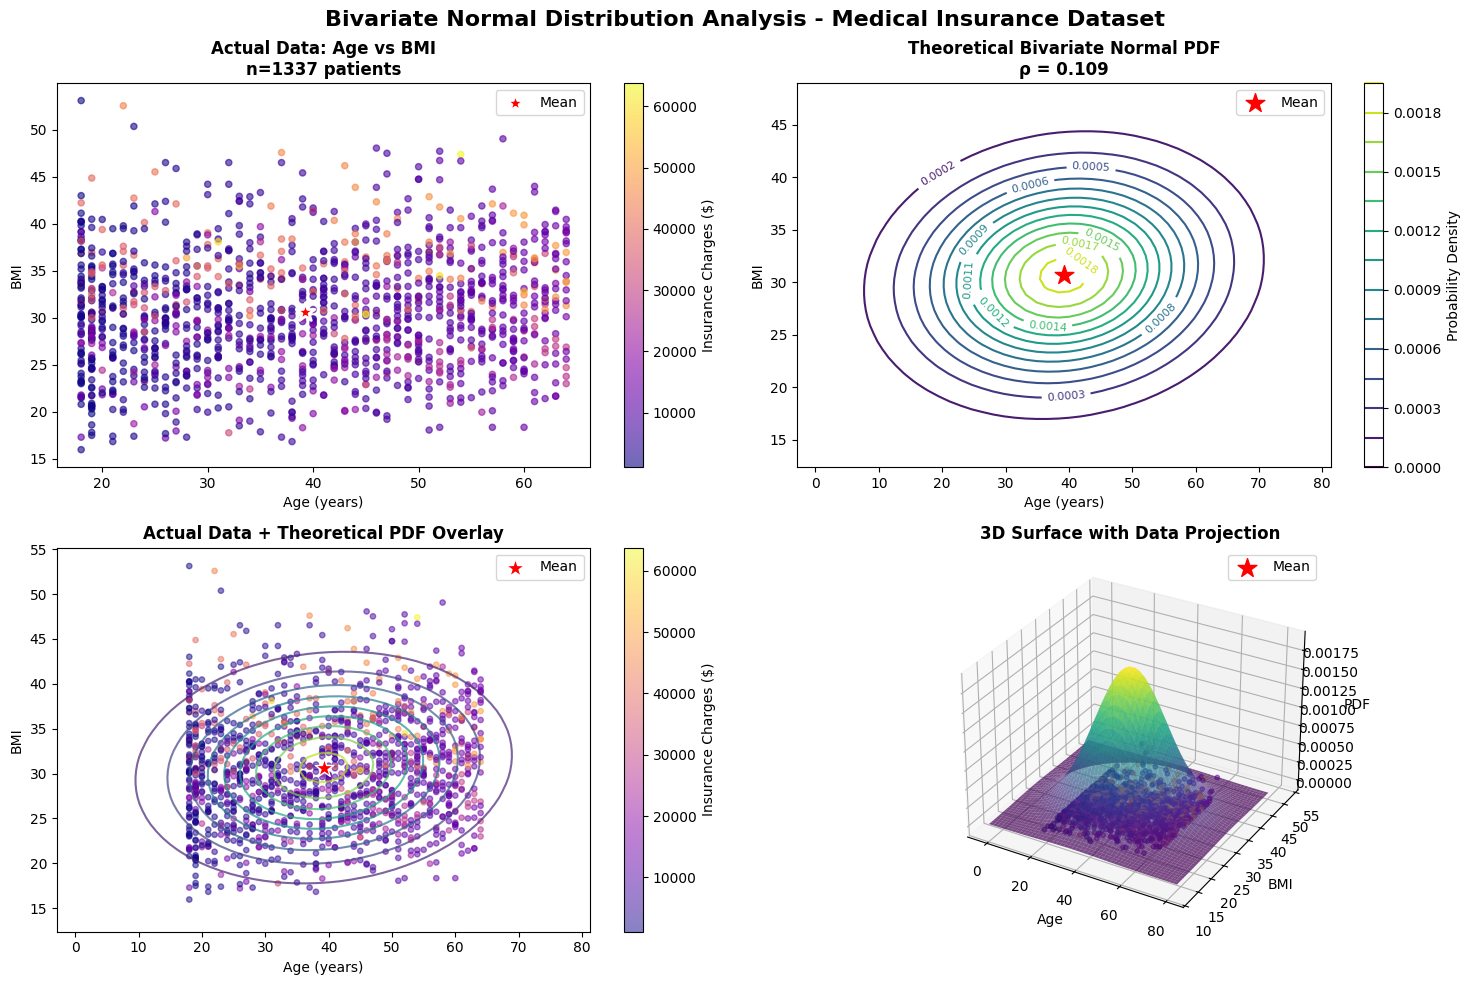


FINAL SUMMARY - BIVARIATE NORMAL DISTRIBUTION ANALYSIS

DATASET: Medical Insurance (1337 patients)
VARIABLES: Age (years) and BMI

KEY FINDINGS:
─────────────
1. Population Characteristics:
   • Average patient: 39.2 years old with BMI 30.7
   • Age range: 18 to 64 years
   • BMI range: 16.0 to 53.1

2. Distribution Properties:
   • Correlation coefficient: 0.1093 (weak positive)
   • Age standard deviation: 14.04 years
   • BMI standard deviation: 6.10
   • Peak probability density: 0.001864

3. Validation Checks:
   • Total probability integral: 0.9956 (✓ should be 1.0)
   • Peak at mean: Age 38.4 vs 39.2 (✓)
   • 1σ probability: 0.393 vs theoretical 0.393 (✓)

4. Interpretation:
   The bivariate normal distribution provides a reasonable theoretical model
   for the joint distribution of Age and BMI in this medical insurance dataset.
   The weak correlation (ρ=0.109) indicates that age and BMI are nearly independent,
   meaning that knowing a patient's age gives little information a

In [25]:
# Combined Visualization (Actual Data + Theoretical PDF)
fig = plt.figure(figsize=(15, 10))

# Create a 2x2 grid of subplots
ax1 = fig.add_subplot(221)
ax2 = fig.add_subplot(222)
ax3 = fig.add_subplot(223)
ax4 = fig.add_subplot(224, projection='3d')

# Plot 1: Actual data scatter
scatter = ax1.scatter(X, Y, c=df['charges'], cmap='plasma', alpha=0.6, s=20)
ax1.scatter(mu_x, mu_y, color='red', s=200, marker='*', label='Mean', edgecolor='white', linewidth=2)
ax1.set_xlabel('Age (years)')
ax1.set_ylabel('BMI')
ax1.set_title(f'Actual Data: Age vs BMI\nn={len(X)} patients', fontweight='bold')
ax1.legend()
plt.colorbar(scatter, ax=ax1, label='Insurance Charges ($)')

# Plot 2: Theoretical PDF contours
contour = ax2.contour(X_grid, Y_grid, Z, levels=15, cmap='viridis')
ax2.clabel(contour, inline=True, fontsize=8, fmt='%.4f')
ax2.scatter(mu_x, mu_y, color='red', s=200, marker='*', label='Mean')
ax2.set_xlabel('Age (years)')
ax2.set_ylabel('BMI')
ax2.set_title(f'Theoretical Bivariate Normal PDF\nρ = {rho:.3f}', fontweight='bold')
ax2.legend()
plt.colorbar(contour, ax=ax2, label='Probability Density')

# Plot 3: Overlay actual data on contours
ax3.contour(X_grid, Y_grid, Z, levels=10, cmap='viridis', alpha=0.7)
scatter2 = ax3.scatter(X, Y, c=df['charges'], cmap='plasma', alpha=0.5, s=15)
ax3.scatter(mu_x, mu_y, color='red', s=200, marker='*', label='Mean', edgecolor='white')
ax3.set_xlabel('Age (years)')
ax3.set_ylabel('BMI')
ax3.set_title('Actual Data + Theoretical PDF Overlay', fontweight='bold')
ax3.legend()
plt.colorbar(scatter2, ax=ax3, label='Insurance Charges ($)')

# Plot 4: 3D surface with actual data points projected
surf = ax4.plot_surface(X_grid, Y_grid, Z, cmap='viridis', alpha=0.7, edgecolor='none')

ax4.scatter(X, Y, np.zeros_like(X), c=df['charges'], cmap='plasma', alpha=0.5, s=10)
ax4.scatter([mu_x], [mu_y], [0], color='red', s=200, marker='*', label='Mean')
ax4.set_xlabel('Age')
ax4.set_ylabel('BMI')
ax4.set_zlabel('PDF')
ax4.set_title('3D Surface with Data Projection', fontweight='bold')
ax4.legend()

plt.suptitle('Bivariate Normal Distribution Analysis - Medical Insurance Dataset', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Final summary
print("\n" + "="*70)
print("FINAL SUMMARY - BIVARIATE NORMAL DISTRIBUTION ANALYSIS")
print("="*70)
print(f"""
DATASET: Medical Insurance (1337 patients)
VARIABLES: Age (years) and BMI

KEY FINDINGS:
─────────────
1. Population Characteristics:
   • Average patient: {mu_x:.1f} years old with BMI {mu_y:.1f}
   • Age range: {np.min(X):.0f} to {np.max(X):.0f} years
   • BMI range: {np.min(Y):.1f} to {np.max(Y):.1f}

2. Distribution Properties:
   • Correlation coefficient: {rho:.4f} (weak positive)
   • Age standard deviation: {sigma_x:.2f} years
   • BMI standard deviation: {sigma_y:.2f}
   • Peak probability density: {peak_value:.6f}

3. Validation Checks:
   • Total probability integral: {total_probability:.4f} (✓ should be 1.0)
   • Peak at mean: Age {peak_age:.1f} vs {mu_x:.1f} (✓)
   • 1σ probability: {prob_1sigma:.3f} vs theoretical 0.393 (✓)

4. Interpretation:
   The bivariate normal distribution provides a reasonable theoretical model
   for the joint distribution of Age and BMI in this medical insurance dataset.
   The weak correlation (ρ=0.109) indicates that age and BMI are nearly independent,
   meaning that knowing a patient's age gives little information about their BMI.
""")